# 01 · Data Cleaning & Panel Construction

Cleans the four raw FRED pulls (median income, minimum wage, poverty rate,
unemployment) and merges them into a single state-year panel: 50 states x
1995-2024, no nulls, no duplicate keys. See `data/DATA_NOTES.md` for the full
reasoning behind every cleaning decision made below.

| | |
|---|---|
| **Input** | `data/raw/*.csv` |
| **Output** | `data/processed/state_panel_1995_2024.csv` (+ one cleaned CSV per variable), `figures/06_median_income_all_states.png`, `figures/07_arizona_effective_wage_check.png` |
| **Next** | `02_eda.ipynb` |

**Contents**
1. Median household income
2. Minimum wage
3. Poverty rate
4. Unemployment rate
5. Merge into final panel

In [1]:
import sys
sys.path.append("../src")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from style import *

apply_style()

## 1. Median Household Income

Source: FRED (`MEHOINUS{STATE}A646N`), annual, 1984-2024, Census-derived.

In [2]:
median_income = pd.read_csv("../data/raw/median_income.csv")
median_income.head()

,state,date,value
0,AL,1984-01-01,17310.0
1,AL,1985-01-01,18330.0
2,AL,1986-01-01,19130.0
3,AL,1987-01-01,19730.0
4,AL,1988-01-01,19950.0


### Inspect

In [3]:
median_income.shape
# 2050 rows, 3 columns

median_income['state'].unique()
# 50 unique states - no DC, Puerto Rico, or other territories

median_income['state'].value_counts()
# 41 entries per state, expected: 1984-2024 is 41 years

median_income.info()
# No null values

<class 'pandas.DataFrame'>
RangeIndex: 2050 entries, 0 to 2049
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   state   2050 non-null   str    
 1   date    2050 non-null   str    
 2   value   2050 non-null   float64
dtypes: float64(1), str(2)
memory usage: 48.2 KB


In [4]:
median_income['date'] = pd.to_datetime(median_income['date'])

median_income['date'].min()
# Timestamp('1984-01-01')

median_income['date'].max()
# Timestamp('2024-01-01')

# Confirm date coverage is identical across every state
date_counts = median_income.groupby('state')['date'].nunique()
date_counts.value_counts()
# Consistent: 41 unique dates for every state

date
41    50
Name: count, dtype: int64

### Transform

In [5]:
median_income['year'] = median_income['date'].dt.year
median_income['state'] = median_income['state'].astype('category')
median_income = median_income.rename(columns={'value': 'median_income'})
median_income = median_income.sort_values(by=['state', 'year']).reset_index(drop=True)

### Visual check

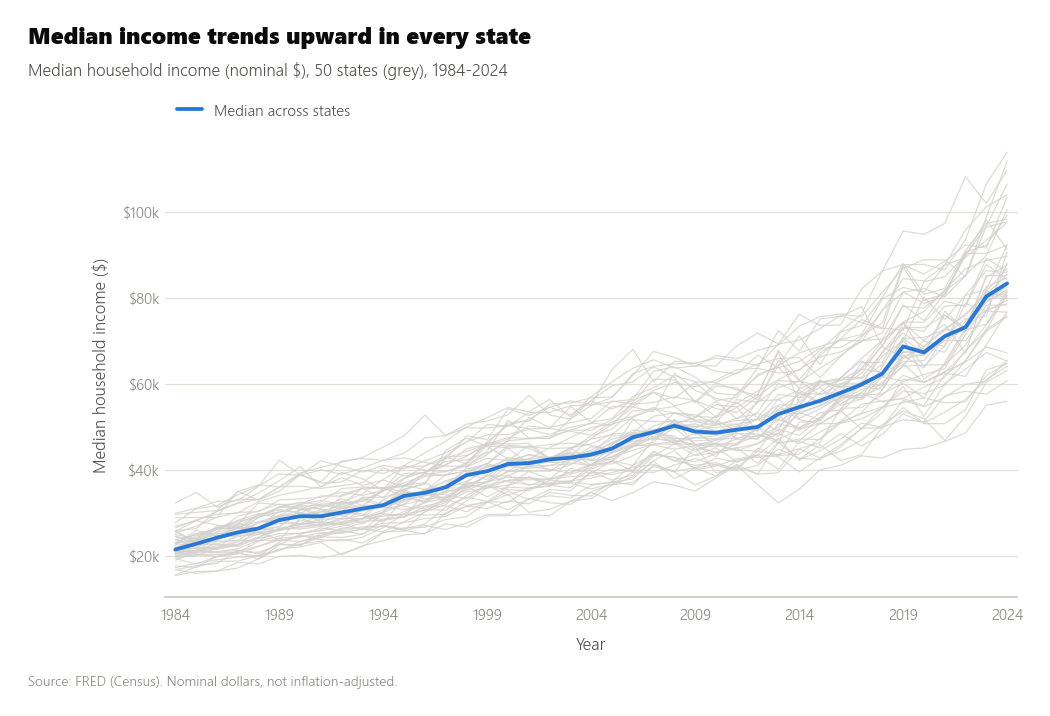

In [6]:
fig, ax = plt.subplots()

for state, sub in median_income.groupby('state', observed=True):
    ax.plot(sub['year'], sub['median_income'], color=CONTEXT, linewidth=0.8, alpha=0.8)

national = median_income.groupby('year')['median_income'].median()
ax.plot(national.index, national.values, color=PRIMARY, linewidth=2.5, label='Median across states')

ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"${v/1000:.0f}k"))
ax.set_xlabel('Year')
ax.set_ylabel(VAR_LABELS['median_income'])
year_axis(ax, 1984, 2024, 5)
legend_row(ax)
titles(fig, 'Median income trends upward in every state',
       'Median household income (nominal $), 50 states (grey), 1984-2024', legend=True)
source_note(fig, 'Source: FRED (Census). Nominal dollars, not inflation-adjusted.')
save_fig(fig, '06_median_income_all_states')
plt.show()
# General upward trend across all states, with some fluctuation

### Save

In [7]:
median_income_final = median_income.drop(columns=['date'])
median_income_final.dtypes

state            category
median_income     float64
year                int32
dtype: object

In [8]:
median_income_final.to_csv("../data/processed/median_income_cleaned.csv", index=False)

## 2. Minimum Wage

Source: FRED (`STTMINWG{STATE}`), annual, 1968-2026. Reports each state's own
statutory rate - does not account for the federal floor, so the effective
(legally binding) rate still needs to be derived below.

In [9]:
min_wage = pd.read_csv("../data/raw/min_wage.csv")
min_wage.head()

,state,date,value
0,AL,1968-01-01,1.6
1,AL,1969-01-01,1.6
2,AL,1970-01-01,1.6
3,AL,1971-01-01,1.6
4,AL,1972-01-01,1.6


### Inspect

In [10]:
min_wage.shape
# 2782 rows, 3 columns

min_wage['state'].unique()
# 50 unique states - no DC, Puerto Rico, or other territories

min_wage.info()
# No null values

<class 'pandas.DataFrame'>
RangeIndex: 2782 entries, 0 to 2781
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   state   2782 non-null   str    
 1   date    2782 non-null   str    
 2   value   2782 non-null   float64
dtypes: float64(1), str(2)
memory usage: 65.3 KB


In [11]:
min_wage['state'].value_counts().value_counts().sort_index()
# Most states have 59 entries, but several have fewer - some states
# established a state minimum wage law later than 1968, so earlier years
# simply don't exist in FRED's series for them.

count
20     1
21     1
36     2
48     1
51     1
52     1
55     3
56     1
57     2
59    37
Name: count, dtype: int64

In [12]:
min_wage['date'] = pd.to_datetime(min_wage['date'])

min_wage['date'].min()
# Timestamp('1968-01-01')

min_wage['date'].max()
# Timestamp('2026-01-01')

min_wage['year'] = min_wage['date'].dt.year
min_wage[['date', 'year']].head()

,date,year
0,1968-01-01,1968
1,1969-01-01,1969
2,1970-01-01,1970
3,1971-01-01,1971
4,1972-01-01,1972


### Federal floor

In [13]:
# Federal minimum wage by year, from FLSA history - used both to fill
# state-year gaps and to compute the effective (binding) minimum wage below.
federal_wage_by_year = {
    1968: 1.60, 1969: 1.60, 1970: 1.60, 1971: 1.60, 1972: 1.60, 1973: 1.60,
    1974: 2.00, 1975: 2.10, 1976: 2.30, 1977: 2.30, 1978: 2.65, 1979: 2.90,
    1980: 3.10, 1981: 3.35, 1982: 3.35, 1983: 3.35, 1984: 3.35, 1985: 3.35,
    1986: 3.35, 1987: 3.35, 1988: 3.35, 1989: 3.35, 1990: 3.80, 1991: 4.25,
    1992: 4.25, 1993: 4.25, 1994: 4.25, 1995: 4.25, 1996: 4.75, 1997: 5.15,
    1998: 5.15, 1999: 5.15, 2000: 5.15, 2001: 5.15, 2002: 5.15, 2003: 5.15,
    2004: 5.15, 2005: 5.15, 2006: 5.15, 2007: 5.85, 2008: 6.55, 2009: 7.25,
    2010: 7.25, 2011: 7.25, 2012: 7.25, 2013: 7.25, 2014: 7.25, 2015: 7.25,
    2016: 7.25, 2017: 7.25, 2018: 7.25, 2019: 7.25, 2020: 7.25, 2021: 7.25,
    2022: 7.25, 2023: 7.25, 2024: 7.25, 2025: 7.25, 2026: 7.25
}

### Fill gaps & derive the effective wage

In [14]:
# Fill missing state-years with the federal minimum wage for that year.
# Applied generally to any gap, not just a hardcoded list of states -
# covers both states that never had a state law and states that adopted
# one partway through the sample.
new_rows = []
for state in min_wage['state'].unique():
    state_years = set(min_wage[min_wage['state'] == state]['year'])
    for year in range(1968, 2027):
        if year not in state_years:
            federal_wage = federal_wage_by_year[year]
            new_rows.append({
                'state': state,
                'date': pd.Timestamp(f'{year}-01-01'),
                'value': federal_wage,
                'year': year
            })

if new_rows:
    min_wage = pd.concat([min_wage, pd.DataFrame(new_rows)], ignore_index=True)

min_wage['state'].value_counts().unique()
# Every state now has 59 entries, matching 1968-2026

array([59])

In [15]:
# The effective minimum wage is the higher of the state rate and the federal
# rate - federal law binds whenever a state's own rate would be lower.
min_wage['federal_floor'] = min_wage['year'].map(federal_wage_by_year)
min_wage['effective_min_wage'] = np.maximum(min_wage['value'], min_wage['federal_floor'])

min_wage = min_wage.sort_values(by=['state', 'year']).reset_index(drop=True)

### Visual check

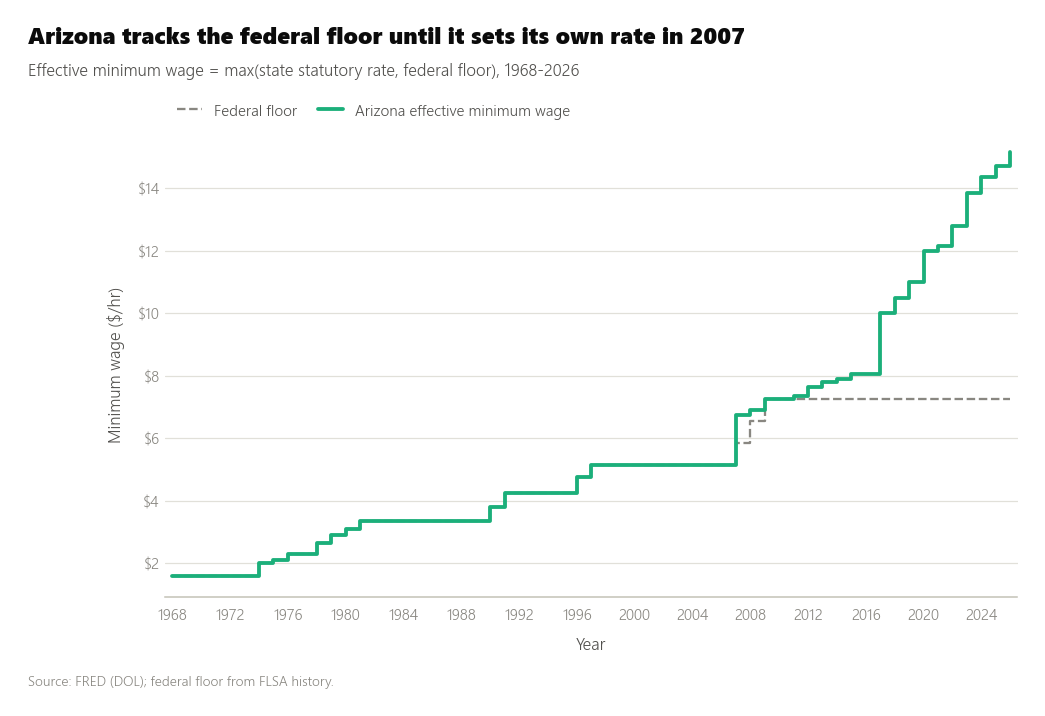

In [16]:
# Spot check one state to confirm the effective-wage logic looks right
az = min_wage[min_wage['state'] == 'AZ']

fig, ax = plt.subplots()
ax.step(az['year'], az['federal_floor'], where='post', color=INK_MUTED,
        linewidth=1.5, linestyle='--', label='Federal floor')
ax.step(az['year'], az['effective_min_wage'], where='post', color=STATE_COLORS['AZ'],
        linewidth=2.5, label='Arizona effective minimum wage')

ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"${v:.0f}"))
ax.set_xlabel('Year')
ax.set_ylabel(VAR_LABELS['effective_min_wage'])
year_axis(ax, 1968, 2026, 4)
legend_row(ax)
titles(fig, 'Arizona tracks the federal floor until it sets its own rate in 2007',
       'Effective minimum wage = max(state statutory rate, federal floor), 1968-2026', legend=True)
source_note(fig, 'Source: FRED (DOL); federal floor from FLSA history.')
save_fig(fig, '07_arizona_effective_wage_check')
plt.show()

### Save

In [17]:
min_wage['state'] = min_wage['state'].astype('category')

min_wage_final = min_wage.drop(columns=['value', 'date', 'federal_floor'])

min_wage_final.info()

<class 'pandas.DataFrame'>
RangeIndex: 2950 entries, 0 to 2949
Data columns (total 3 columns):
 #   Column              Non-Null Count  Dtype   
---  ------              --------------  -----   
 0   state               2950 non-null   category
 1   year                2950 non-null   int64   
 2   effective_min_wage  2950 non-null   float64 
dtypes: category(1), float64(1), int64(1)
memory usage: 49.5 KB


In [18]:
min_wage_final.to_csv('../data/processed/min_wage_cleaned.csv', index=False)

## 3. Poverty Rate

Source: FRED (`PPAA{STATE}{FIPS}A156NCEN`), annual, 1989-2024, Census SAIPE
program.

In [19]:
poverty_rate = pd.read_csv('../data/raw/poverty_rate.csv')
poverty_rate.head()
# Null values already present in the value column

,state,date,value
0,AL,1989-01-01,17.7
1,AL,1990-01-01,NaN
2,AL,1991-01-01,NaN
3,AL,1992-01-01,NaN
4,AL,1993-01-01,18.8


### Inspect

In [20]:
poverty_rate.shape
# 1800 rows, 3 columns

poverty_rate['state'].unique()
# 50 unique states

poverty_rate['state'].value_counts()
# 36 entries per state, expected: 1989-2024 is 36 years.
# So the value column is the only thing that needs fixing - some
# dates exist with no corresponding value.

poverty_rate.info()
# 200 nulls in the value column

<class 'pandas.DataFrame'>
RangeIndex: 1800 entries, 0 to 1799
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   state   1800 non-null   str    
 1   date    1800 non-null   str    
 2   value   1600 non-null   float64
dtypes: float64(1), str(2)
memory usage: 42.3 KB


In [21]:
poverty_rate['date'] = pd.to_datetime(poverty_rate['date'])

poverty_rate['date'].min()
# Timestamp('1989-01-01')

poverty_rate['date'].max()
# Timestamp('2024-01-01')

poverty_rate['year'] = poverty_rate['date'].dt.year
poverty_rate['state'] = poverty_rate['state'].astype('category')

### Locate the missing years

In [22]:
# Inspect where the nulls actually fall
poverty_rate.groupby('state', observed=True)['value'].count().unique()
# 36 years per state, but only 32 non-null values for every state - a
# consistent pattern, not random missingness

array([32])

In [23]:
counts_by_year = poverty_rate.groupby('year')['value'].count()
counts_by_year[counts_by_year < 50]
# Confirmed: 1990, 1991, 1992, and 1994 have no data for any state.
# This is a documented gap in the Census SAIPE program's early history -
# estimates exist for 1989, then a gap, then 1993, then another gap, then
# continuously from 1995 onward. Not a flaw in the FRED pull.

year
1990    0
1991    0
1992    0
1994    0
Name: value, dtype: int64

### Restrict to 1995-2024

In [24]:
# Dropping all years before 1995 rather than keeping an unbalanced panel -
# 1989 and 1993 are two isolated points that aren't worth the added
# complexity, and 1995-2024 is fully continuous across all four variables.
yrs_to_exclude = [i for i in range(1989, 1995)]
poverty_rate = poverty_rate[~poverty_rate['year'].isin(yrs_to_exclude)]

poverty_rate['year'].agg(['min', 'max']), poverty_rate['value'].isna().sum()
# Confirmed: years now range 1995-2024, no nulls

(min    1995
 max    2024
 Name: year, dtype: int32,
 np.int64(0))

### Save

In [25]:
poverty_rate_final = poverty_rate.drop(columns=['date'])
poverty_rate_final = poverty_rate_final.sort_values(by=['state', 'year'])
poverty_rate_final = poverty_rate_final.rename(columns={'value': 'pct_poverty'})

poverty_rate_final.info()

<class 'pandas.DataFrame'>
Index: 1500 entries, 42 to 1799
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   state        1500 non-null   category
 1   pct_poverty  1500 non-null   float64 
 2   year         1500 non-null   int32   
dtypes: category(1), float64(1), int32(1)
memory usage: 31.2 KB


In [26]:
poverty_rate_final.to_csv('../data/processed/poverty_rate_cleaned.csv', index=False)

## 4. Unemployment Rate

Source: FRED (`{STATE}UR`), monthly, seasonally adjusted. Collapsed to annual
below since every other variable in the panel is annual.

In [27]:
unemployment = pd.read_csv('../data/raw/unemployment.csv')
unemployment.head()

,state,date,value
0,AL,1976-01-01,6.7
1,AL,1976-02-01,6.6
2,AL,1976-03-01,6.6
3,AL,1976-04-01,6.5
4,AL,1976-05-01,6.4


### Inspect

In [28]:
# Monthly dataset - needs to be collapsed into annual data
unemployment.info()
# 50 nulls in the value column

<class 'pandas.DataFrame'>
RangeIndex: 30250 entries, 0 to 30249
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   state   30250 non-null  str    
 1   date    30250 non-null  str    
 2   value   30200 non-null  float64
dtypes: float64(1), str(2)
memory usage: 709.1 KB


In [29]:
unemployment['date'] = pd.to_datetime(unemployment['date'])
unemployment['year'] = unemployment['date'].dt.year

unemployment.groupby(['state'])['value'].count().unique()
# 604 values per state - not a per-state problem

array([604])

In [30]:
unemployment.groupby(['year'])['value'].count().tail()
# 600 (50 states x 12 months) for every year except 2025 and 2026,
# which are incomplete going forward - this accounts for the 50 nulls

year
2022    600
2023    600
2024    600
2025    550
2026    250
Name: value, dtype: int64

### Drop incomplete years & verify coverage

In [31]:
unemployment = unemployment[~unemployment['year'].isin([2025, 2026])]

unemployment.isna().sum()
# Nulls resolved

state    0
date     0
value    0
year     0
dtype: int64

In [32]:
# Confirm every state-year has all 12 months before averaging
unemployment['month'] = unemployment['date'].dt.month
monthly_count = unemployment.groupby(['year', 'month'])['value'].agg(['count'])
monthly_count['count'].min(), monthly_count['count'].max()
# (50, 50) - every year-month has exactly 50 states, safe to collapse to annual

(np.int64(50), np.int64(50))

### Annualize

In [33]:
unemployment['state'] = unemployment['state'].astype('category')
unemployment = unemployment.drop(columns=['date', 'month'])
unemployment = unemployment.rename(columns={'value': 'pct_unemployed'})

# Annualize: calendar-year mean of the 12 monthly values. Chosen over a
# single point-in-time value (e.g. December) since unemployment is a
# continuously fluctuating rate, best represented by a full-year average -
# unlike minimum wage, which is a policy level set on a specific date.
unemployment = unemployment.groupby(['state', 'year'], observed=True).agg(pct_unemployed=('pct_unemployed', 'mean'))
unemployment = unemployment.reset_index()

unemployment['pct_unemployed'] = round(unemployment['pct_unemployed'], 1)

unemployment.info()

<class 'pandas.DataFrame'>
RangeIndex: 2450 entries, 0 to 2449
Data columns (total 3 columns):
 #   Column          Non-Null Count  Dtype   
---  ------          --------------  -----   
 0   state           2450 non-null   category
 1   year            2450 non-null   int32   
 2   pct_unemployed  2450 non-null   float64 
dtypes: category(1), float64(1), int32(1)
memory usage: 31.6 KB


### Save

In [34]:
unemployment.to_csv('../data/processed/unemployment_cleaned.csv', index=False)

## 5. Merge Into Final Panel

Inner join on (state, year) across all four cleaned tables. Poverty is the
binding constraint (1995-2024), and its range is a subset of the other
three, so the inner join collapses to exactly that window without any
additional filtering needed.

In [35]:
panel = (
    unemployment
    .merge(min_wage_final, on=['state', 'year'], how='inner')
    .merge(median_income_final, on=['state', 'year'], how='inner')
    .merge(poverty_rate_final, on=['state', 'year'], how='inner')
)

### Validate

In [36]:
assert panel.shape[0] == 50 * 30                                  # 1,500 - 50 states x 1995-2024
assert (panel['year'].min(), panel['year'].max()) == (1995, 2024)
assert panel.isna().sum().sum() == 0                              # no nulls
assert not panel.duplicated(['state', 'year']).any()              # no duplicate keys
print("Panel checks passed:", panel.shape)

Panel checks passed: (1500, 6)


### Flag states above the federal floor

In [37]:
# Flag which state-years exceeded the federal floor, reusing the same
# FLSA federal wage history from Section 2
panel['federal_floor'] = panel['year'].map(federal_wage_by_year)
panel['above_federal_floor'] = (panel['effective_min_wage'] > panel['federal_floor']).astype(int)
panel = panel.drop(columns=['federal_floor'])

panel.head()

,state,year,pct_unemployed,effective_min_wage,median_income,pct_poverty,above_federal_floor
0,AK,1995,7.3,4.75,47950.0,10.1,1
1,AK,1996,7.5,4.75,52780.0,10.6,0
2,AK,1997,7.0,5.25,47990.0,11.2,1
3,AK,1998,6.3,5.65,50690.0,10.8,1
4,AK,1999,6.4,5.65,51400.0,8.8,1


### Save

In [38]:
panel.to_csv('../data/processed/state_panel_1995_2024.csv', index=False)